In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

In [23]:
y = np.array([0.18, 0.32, 0.42, 0.49, 0.54])
t = np.array([1, 2, 3, 4, 5], dtype=float)
sigma2 = 1e-3

In [24]:
def a_ox(x1):
	return 0.4 + 0.4 * (1.0 + erf(x1 / np.sqrt(2.0)))

def b_ox(x2):
	return 0.01 + 0.15 * (1.0 + erf(x2 / np.sqrt(2.0)))

def B_model(t, x):
	x1, x2 = x[0], x[1]
	return a_ox(x1) * (1.0 - np.exp(-b_ox(x2) * t))

def log_prior(x):
	return -0.5 * np.dot(x, x)

def log_likelihood(x):
	pred = B_model(t, x)
	r = y - pred
	return -0.5 * np.sum(r * r) / sigma2

def log_posterior(x):
	return log_likelihood(x) + log_prior(x)

In [25]:
def rwm(n_iter, step = 0.2, seed = 987):
	""" classic random walk metroplis to sample from the posterior distribution defined as pi^y """

	# random seed
	rng = np.random.default_rng(seed)

	# starting point
	x = np.zeros(2, dtype = float)

	# our chain
	chain = np.zeros((n_iter, 2))

	acc_count = 0

	for i in range(1, n_iter):

		# acceptance probability
		u = np.log(rng.uniform())

		# proposed step
		xp = x + step * rng.normal(size = 2)

		if u < (log_posterior(xp) - log_posterior(x)):
			x = xp
			acc_count += 1

		# update the chain
		chain[i] = x

	return chain, acc_count / n_iter

In [26]:
def acf_2d(chain, max_lag = 2000):
	""" autocorrelation function """

	chain = np.asarray(chain, dtype=float)

	mean = chain.mean(axis=0)
	chain_centered = chain - mean

	# total variance (trace of covariance)
	var = np.mean(np.sum(chain_centered * chain_centered, axis=1))

	out = np.zeros(max_lag + 1)
	out[0] = 1.0

	# autocorrelation for each lag from 1 to max_lag
	for k in range(1, max_lag + 1):
		num = np.mean(np.sum(chain_centered[:-k] * chain_centered[k:], axis=1))
		out[k] = num / var

	return out

In [27]:
def ess_2d(chain, max_lag = 2000):
	""" effective sample size """

	# the list of autocorrelations
	acf = acf_2d(chain, max_lag = max_lag)

	s = 0.0

	# until we get a negative autocorrelation we keep adding to s
	for k in range(1, len(acf)):
		if acf[k] < 0:
			break
		s += acf[k]

	return len(chain) / (1.0 + 2.0 * s)

In [28]:
n_iter = 25000
burn = 1000
step = 0.18

chain, acc_rate = rwm(n_iter = n_iter, step = step, seed = 123)

post_burning = chain[burn:]

# posterior means
mean_chain = post_burning.mean(axis = 0)

# global ess
ess = ess_2d(post_burning, max_lag = 2000)

print("acceptance rate:", round(acc_rate, 3))
print("e[x|y] is approximately equal to", mean_chain)
print("effective sample size is approximately", int(ess), "over", len(post_burning))


acceptance rate: 0.427
e[x|y] is approximately equal to [0.01454278 0.97194366]
effective sample size is approximately 133 over 24000


In [29]:
np.save("posterior_samples.npy", post_burning)

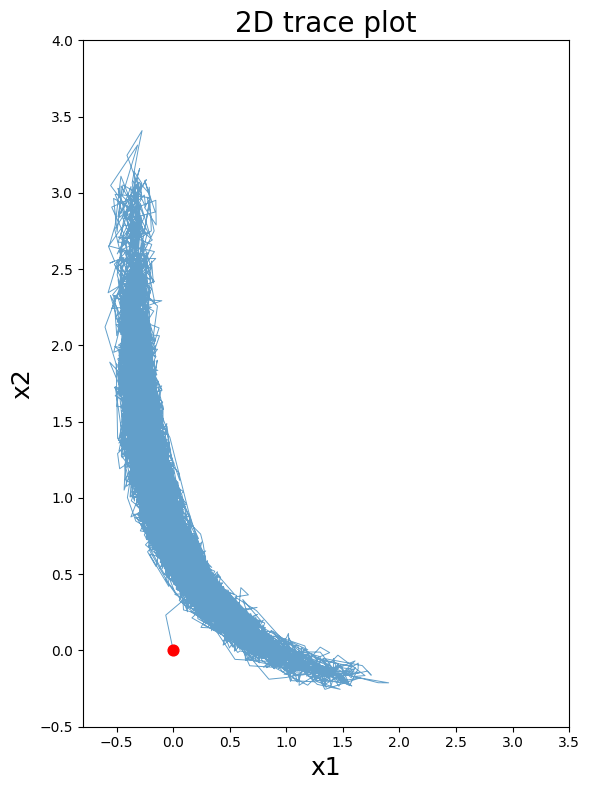

In [30]:
# 2d trace plot
plt.figure(figsize=(6, 8))

plt.plot(chain[:, 0], chain[:, 1], linewidth=0.7, alpha=0.7)

# starting point
plt.scatter(chain[0, 0], chain[0, 1], color="red", s=60, zorder=3)

plt.xlabel("x1", fontsize=18)
plt.ylabel("x2", fontsize=18)
plt.title("2D trace plot", fontsize=20)
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)

plt.tight_layout()
plt.show()

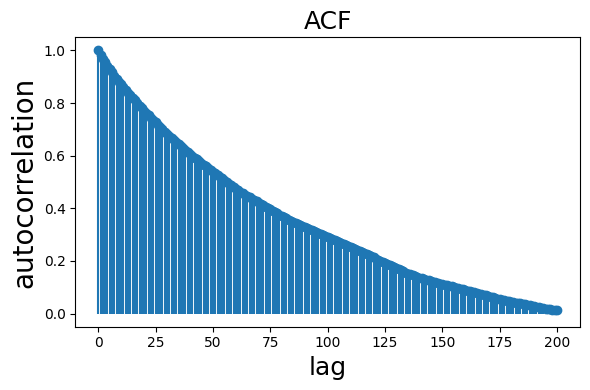

In [31]:
# acf 2D
max_lag = 200
acf = acf_2d(chain, max_lag)

fig, ax = plt.subplots(figsize=(6, 4))
ax.stem(range(max_lag + 1), acf, basefmt=" ", markerfmt="o")
ax.set_title("ACF", fontsize = 18)
ax.set_xlabel("lag", fontsize = 18)
ax.set_ylabel("autocorrelation", fontsize = 20)

plt.tight_layout()
plt.show()


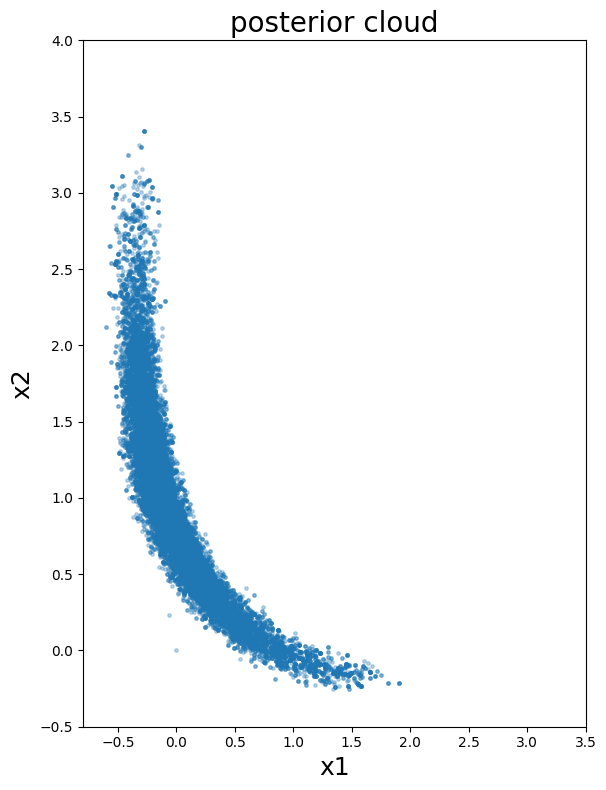

In [32]:
# posterior cloud
x1 = chain[:, 0]
x2 = chain[:, 1]
plt.figure(figsize=(6, 8))
plt.scatter(x1, x2, s=6, alpha=0.3)
plt.title("posterior cloud", fontsize = 20)
plt.xlabel("x1", fontsize = 18)
plt.ylabel("x2", fontsize = 18)
plt.tight_layout()
plt.ylim(-0.5, 4)
plt.xlim(-0.8, 3.5)
plt.show()

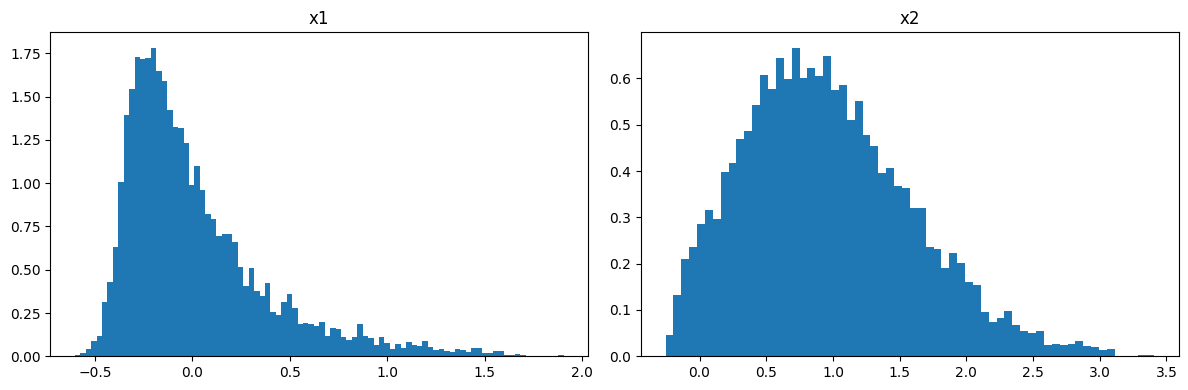

In [33]:
# marginals
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(x1, bins="auto", density=True)
ax[0].set_title("x1")
ax[1].hist(x2, bins="auto", density=True)
ax[1].set_title("x2")
plt.tight_layout()
plt.show()